In [17]:
# ── Imports (run this first) ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

data = load_iris()
X_raw  = data.data
y_true = data.target
feature_names = [n.replace(' (cm)', '') for n in data.feature_names]
class_names   = data.target_names
print("Dataset loaded:", X_raw.shape, "→", dict(zip(class_names, np.bincount(y_true))))

Dataset loaded: (150, 4) → {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}


## Step 1: Standardize the Data

PCA is sensitive to scale. A feature measured in kilometres will dominate one measured in grams purely because of its larger numbers, not because it is more informative.

### Mean-centring
Subtract the mean of each feature so the data cloud sits at the origin:
$$\tilde{x}_{ij} = x_{ij} - \bar{x}_j$$

### Standardisation (z-score)
Divide by the standard deviation so all features have unit variance:
$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{\sigma_j}$$

> Remember: **Always standardise before PCA** unless your features are already on the same scale and you explicitly want to weight by raw variance.

Once we standardize, **mean becomes 0 and standard deviation becomes 1**; ensures all features contribute equally.



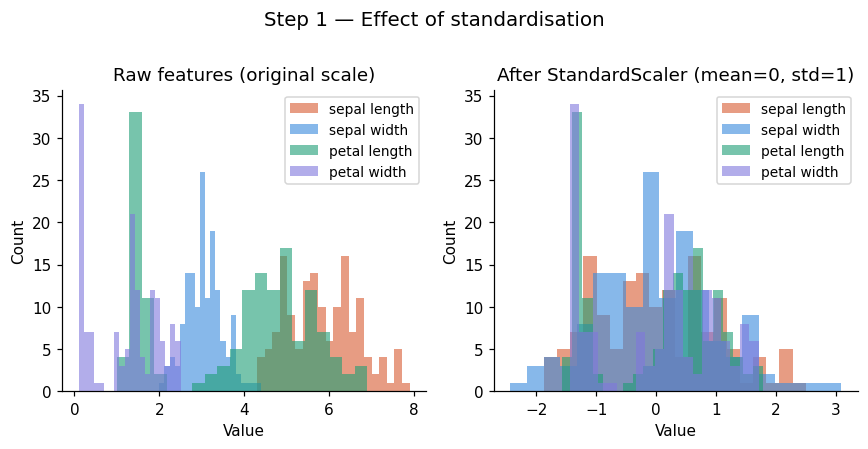

Means  (should be ~0): [-0. -0. -0. -0.]
StdDevs (should be ~1): [1. 1. 1. 1.]


In [18]:
# ── Step 1: standardise ───────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
colors = ['#D85A30', '#378ADD', '#1D9E75', '#7F77DD']

for i, (ax, X_plot, title) in enumerate(zip(
        axes,
        [X_raw, X_scaled],
        ['Raw features (original scale)', 'After StandardScaler (mean=0, std=1)'])):
    for j, (fname, col) in enumerate(zip(feature_names, colors)):
        ax.hist(X_plot[:, j], bins=20, alpha=0.6, color=col, label=fname)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Step 1 — Effect of standardisation', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("Means  (should be ~0):", X_scaled.mean(axis=0).round(10))
print("StdDevs (should be ~1):", X_scaled.std(axis=0).round(3))



## Step 2: Compute Covariance Matrix

Before PCA can find anything, it needs to understand how your features relate to each other. This is the job of the **covariance matrix C**.

> **The covariance matrix** tells us **how features vary together.**

| Sign | Meaning |
|------|---------|
| **Positive** | Features increase together |
| **Negative** | One rises as the other falls |
| **Zero** | No linear relationship |

This helps PCA understand relationships between features.


### Formula

For a dataset $X$ with $n$ samples and $p$ features (already **mean-centred**), the covariance matrix is:

$$C = \frac{1}{n-1} X^\top X$$

It is a $p \times p$ **symmetric** matrix where:

- **Diagonal entries** $C_{ii}$ = variance of feature $i$
- **Off-diagonal entries** $C_{ij}$ = covariance between feature $i$ and feature $j$
- **Symmetry**: $C_{ij} = C_{ji}$ always

For a 3-feature dataset it looks like:

$$C = \begin{bmatrix}
\text{Var}(x_1) & \text{Cov}(x_1, x_2) & \text{Cov}(x_1, x_3) \\
\text{Cov}(x_2, x_1) & \text{Var}(x_2) & \text{Cov}(x_2, x_3) \\
\text{Cov}(x_3, x_1) & \text{Cov}(x_3, x_2) & \text{Var}(x_3)
\end{bmatrix}$$


| Entry | Meaning |
|-------|---------|
| Diagonal $C_{ii}$ | Variance of feature $i$ |
| Off-diagonal $C_{ij} > 0$ | Features move together |
| Off-diagonal $C_{ij} < 0$ | Features move oppositely |
| Off-diagonal $C_{ij} = 0$ | No linear relationship |

> **Key insight:** If features are correlated, there are directions in the data space that capture more variance than any single original axis. PCA finds exactly those directions via **eigendecomposition of C**.



Covariance matrix C (4×4):
 [[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]

Max difference vs np.cov: 4.440892098500626e-16


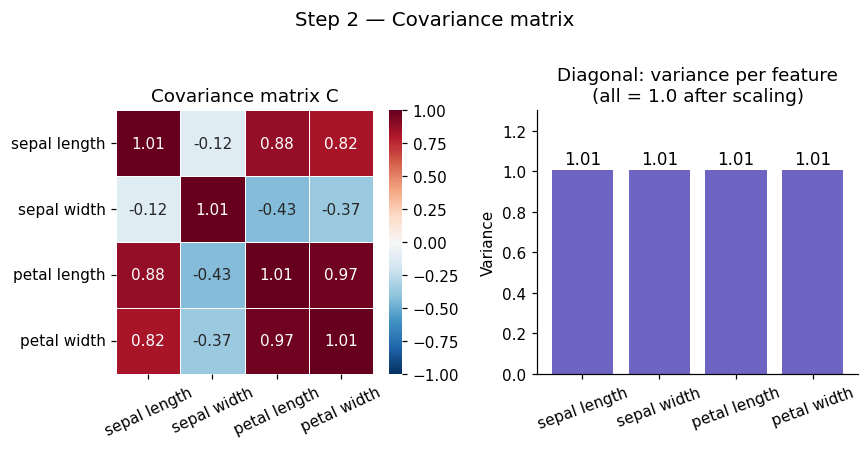

In [19]:
# ── Step 2: covariance matrix ─────────────────────────
n = X_scaled.shape[0]
C = (X_scaled.T @ X_scaled) / (n - 1)

print("Covariance matrix C (4×4):\n", np.round(C, 3))
print("\nMax difference vs np.cov:", np.abs(C - np.cov(X_scaled.T)).max())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.heatmap(C, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=feature_names, yticklabels=feature_names,
            linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Covariance matrix C', fontsize=12)
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(feature_names, np.diag(C), color='#534AB7', alpha=0.85)
axes[1].set_title('Diagonal: variance per feature\n(all = 1.0 after scaling)', fontsize=12)
axes[1].set_ylabel('Variance'); axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 1.3)
for i, v in enumerate(np.diag(C)):
    axes[1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=11)

plt.suptitle('Step 2 — Covariance matrix', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

<!-- ## Step 3: Eigendecomposition

The core of PCA is solving the **eigenvalue problem**:

$$C \mathbf{v} = \lambda \mathbf{v}$$

- $\mathbf{v}$ is an **eigenvector** — a direction in feature space that the covariance matrix merely stretches, never rotates. These are the **principal components**.
- $\lambda$ is the **eigenvalue** — the scalar stretch factor, equal to the **variance captured** along that direction.

### Full decomposition
$$C = V \Lambda V^\top$$

where $V$ is the matrix of eigenvectors (columns) and $\Lambda = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_p)$.

### Properties
- There are exactly $p$ eigenpairs for a $p \times p$ matrix
- Eigenvectors are **orthogonal** (perpendicular) to each other — PCs are uncorrelated by construction
- Sort by $\lambda$ descending: PC1 = maximum variance, PC2 = second most, etc.
- $\sum_i \lambda_i = p$ (total variance equals number of features, after standardisation) -->


## Step 3: Eigendecomposition


The core of PCA is solving the **eigenvalue problem**:


$$C \mathbf{v} = \lambda \mathbf{v}$$

Where:

| Symbol | Name | Role |
|--------|------|------|
| $C$ | Covariance matrix | Encodes all feature relationships |
| $\mathbf{v}$ | **Eigenvector** (direction) | A principal component axis in feature space |
| $\lambda$ | **Eigenvalue** (importance) | Variance captured along that direction |


> Eigenvectors are the directions the covariance matrix only **stretches**, never rotates. Eigenvalues tell you **how much** it stretches — i.e. how much variance lies along that direction.

This gives us our **principal components**, a new set of axes aligned with the natural structure of the data, ordered by how much they explain.


### Properties
- There are exactly $p$ eigenpairs for a $p \times p$ matrix
- Eigenvectors are **orthogonal** (perpendicular) to each other; PCs are uncorrelated by construction
- Sort by $\lambda$ descending: PC1 = maximum variance, PC2 = second most, etc.
- $\sum_i \lambda_i = p$ (total variance equals number of features, after standardisation)


## Step 4: Sort Components

Eigendecomposition returns $p$ eigenpairs in arbitrary order. We sort them so the most informative components come first:

$$\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p$$

- **Sort eigenvalues** in descending order
- **Reorder eigenvectors** to match (each eigenvector travels with its eigenvalue)
- **Select top $k$** eigenvectors — these are your $k$ principal components

> Most important directions first. PC1 always captures the most variance, PC2 the second most, and so on.

Eigenvalues (= variance per PC):
  PC1: λ = 2.9381  (73.0% of variance)
        loadings: [-0.521  0.269 -0.58  -0.565]
  PC2: λ = 0.9202  (22.9% of variance)
        loadings: [0.377 0.923 0.024 0.067]
  PC3: λ = 0.1477  (3.7% of variance)
        loadings: [ 0.72  -0.244 -0.142 -0.634]
  PC4: λ = 0.0209  (0.5% of variance)
        loadings: [ 0.261 -0.124 -0.801  0.524]

Sum of eigenvalues = 4.0  (= p = 4, checks out)


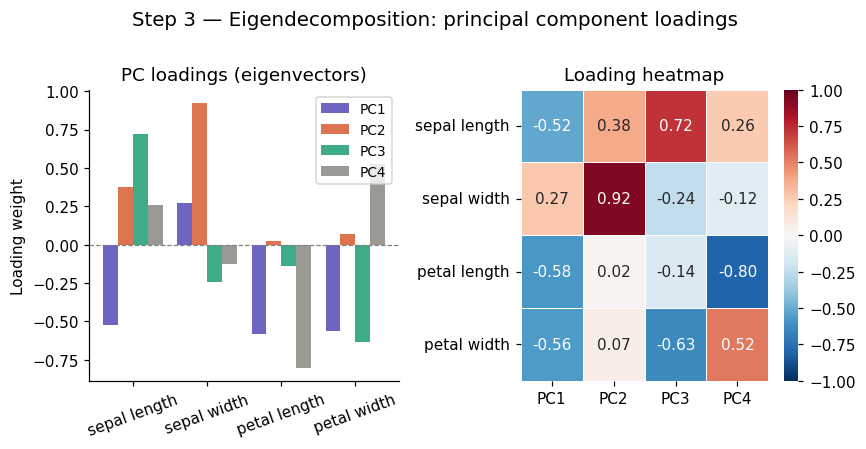

In [20]:
# ── Step 3: eigendecomposition ────────────────────────
eigenvalues, eigenvectors = np.linalg.eigh(C)   # eigh = symmetric matrix, returns real values

# Sort descending
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]             # each COLUMN is a principal component

print("Eigenvalues (= variance per PC):")
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    print(f"  PC{i+1}: λ = {val:.4f}  ({val/eigenvalues.sum()*100:.1f}% of variance)")
    print(f"        loadings: {np.round(vec, 3)}")

print(f"\nSum of eigenvalues = {eigenvalues.sum():.1f}  (= p = {C.shape[0]}, checks out)")

# Visualise loadings (how much each original feature contributes to each PC)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

x = np.arange(len(feature_names))
width = 0.2
pc_colors = ['#534AB7', '#D85A30', '#1D9E75', '#888780']
for i in range(4):
    axes[0].bar(x + i*width, eigenvectors[:, i], width, label=f'PC{i+1}',
                color=pc_colors[i], alpha=0.85)
axes[0].set_xticks(x + width*1.5); axes[0].set_xticklabels(feature_names, rotation=20)
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].set_title('PC loadings (eigenvectors)', fontsize=12)
axes[0].set_ylabel('Loading weight'); axes[0].legend(fontsize=9)

sns.heatmap(eigenvectors, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[f'PC{i+1}' for i in range(4)],
            yticklabels=feature_names, linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Loading heatmap', fontsize=12)

plt.suptitle('Step 3 — Eigendecomposition: principal component loadings', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

Before sorting (eigh returns ascending order):
  pair 1: λ = 0.0209
  pair 2: λ = 0.1477
  pair 3: λ = 0.9202
  pair 4: λ = 2.9381

After sorting (descending):
  PC1: λ = 2.9381  ← most important
  PC2: λ = 0.9202  ← next important
  PC3: λ = 0.1477  ← next important
  PC4: λ = 0.0209  ← least important


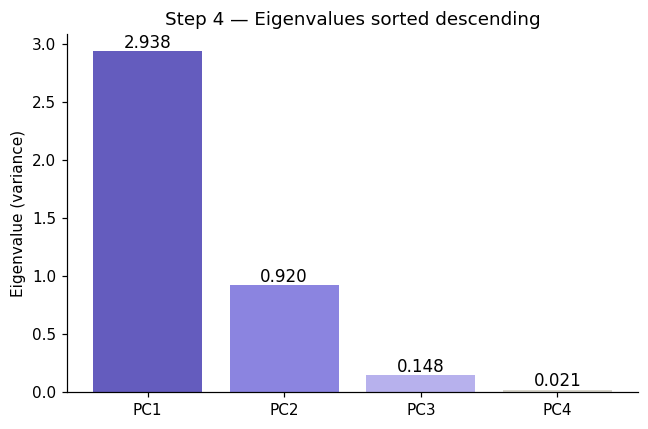

In [21]:
# ── Step 4: sort eigenpairs descending ───────────────
eigenvalues_raw, eigenvectors_raw = np.linalg.eigh(C)

print("Before sorting (eigh returns ascending order):")
for i, (lam, vec) in enumerate(zip(eigenvalues_raw, eigenvectors_raw.T)):
    print(f"  pair {i+1}: λ = {lam:.4f}")

# Sort descending
idx_sorted   = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[idx_sorted]
eigenvectors = eigenvectors_raw[:, idx_sorted]

print("\nAfter sorting (descending):")
for i, lam in enumerate(eigenvalues):
    print(f"  PC{i+1}: λ = {lam:.4f}  ← {'most' if i==0 else 'least' if i==len(eigenvalues)-1 else 'next'} important")

# Visualise sorted eigenvalues
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([f'PC{i+1}' for i in range(len(eigenvalues))],
              eigenvalues, color=['#534AB7','#7F77DD','#AFA9EC','#D3D1C7'], alpha=0.9)
ax.set_ylabel('Eigenvalue (variance)')
ax.set_title('Step 4 — Eigenvalues sorted descending', fontsize=12)
for bar, val in zip(bars, eigenvalues):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.3f}',
            ha='center', fontsize=11)
plt.tight_layout(); plt.show()

## Step 5: Choose Number of Components (k)

We don't always keep all $p$ components; only those that preserve most of the variance. How many components should you keep? We need to know the **explained variance ratio** of PC $i$.

### Explained Variance Ratio (EVR)

Measures how much variance **each individual PC** explains:

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}$$

Example:
- PC1 = 50%
- PC2 = 30%
- PC3 = 20%


### Cumulative Explained Variance (CEV)

Total variance retained by the **first $k$ components combined**:

$$\text{CEV}(k) = \sum_{i=1}^{k} \text{EVR}_i = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{p} \lambda_j}$$

Example:
- First 2 PCs = 80%  
- If threshold = 80% → **keep 2 PCs**




### Rules of thumb for choosing k

| Rule | Description |
|------|-------------|
| **Scree plot elbow** | Pick $k$ where the curve bends — adding more PCs gives diminishing returns |
| **Variance threshold** | Keep enough PCs to explain ≥ 95% (or 90%) of variance |
| **Kaiser criterion** | Keep PCs with $\lambda_i > 1$ (captures more than one average feature's worth of variance) |
| **Downstream task** | For K-Means clustering, 2–10 components is usually sufficient |


<!-- ### Rules of thumb

| Rule | Pick $k$ when... |
|------|------------------|
| **Variance threshold** | CEV ≥ 95% (or 90% for noisier data) |
| **Scree plot elbow** | Curve bends; adding more PCs gives diminishing returns |
| **Kaiser criterion** | Keep PCs where $\lambda_i > 1$ (more than one feature's worth of variance) |
| **Downstream task** | For K-Means, 2–10 components is usually enough | -->


## Step 6: Transform the Data (Projection to Lower Dimensions)

Once you have selected the top $k$ eigenvectors, **project** the data onto them:

$$Z = X \cdot W$$

Where:
- $X$ is the standardised data matrix — shape $(n \times p)$
- $W = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \cdots \mid \mathbf{v}_k]$ — the top $k$ eigenvectors stacked as columns, shape $(p \times k)$
- $Z$ is the **reduced data matrix** — shape $(n \times k)$

### What this achieves

| Before | After |
|--------|-------|
| $n$ samples × $p$ original features | $n$ samples × $k$ principal components |
| Features may be correlated | Components are uncorrelated by construction |
| High-dimensional, noisy | Lower-dimensional, most information preserved |

> The projection is a **rotation** of the coordinate axes; no information is added, only the least-variant dimensions are discarded.

## Benefits and Limitations of PCA

PCA reduces dimensionality, improves computational efficiency, and makes data easier to visualize (especially in 2D or 3D). By removing correlated features, it can also help reduce overfitting.

However, PCA assumes linear relationships, and the resulting components can be difficult to interpret. Since it is unsupervised, it does not consider output labels and may lose some information during compression.


PCA is one of the most important tools for:
- Data preprocessing  
- Noise reduction  
- Feature extraction  
- Visualization  

In [15]:
from IPython.display import HTML

HTML("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>PCA Variance Intuition</title>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { font-family: sans-serif; background: #fff; color: #3d3d3a; padding: 24px; }
  h2 { font-size: 18px; font-weight: 500; margin-bottom: 4px; }
  p { font-size: 14px; color: #5f5e5a; margin-bottom: 16px; }
  canvas { display: block; border: 1px solid #e8e6df; border-radius: 8px; }
  .ctrl { display: flex; align-items: center; gap: 10px; font-size: 13px; color: #5f5e5a; margin: 10px 0 0; }
  .ctrl input { flex: 1; }
  .ctrl span { min-width: 36px; font-size: 13px; color: #2c2c2a; font-weight: 500; }
  .ctrl label { min-width: 90px; }
  .legend { display: flex; gap: 20px; margin: 10px 0 0; font-size: 12px; color: #5f5e5a; }
  .dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; margin-right: 5px; vertical-align: middle; }

  @media (prefers-color-scheme: dark) {
    body { background: #1e1e1c; color: #c2c0b6; }
    h2 { color: #e8e6df; }
    p { color: #888780; }
    canvas { border-color: #3d3d3a; }
    .ctrl { color: #888780; }
    .ctrl span { color: #e8e6df; }
    .legend { color: #888780; }
  }
</style>
</head>
<body>
<h2>PCA — variance intuition</h2>
<p>Drag the sliders to rotate and stretch the data cloud. PC1 always aligns with the direction of maximum variance.</p>

<canvas id="c" width="680" height="340"></canvas>

<div class="ctrl">
  <label>Correlation angle</label>
  <input type="range" id="corr" min="-90" max="90" value="40" step="1">
  <span id="corr-out">40°</span>
</div>
<div class="ctrl">
  <label>Spread ratio</label>
  <input type="range" id="spread" min="1" max="5" value="3" step="0.1">
  <span id="spread-out">3.0×</span>
</div>
<div class="legend">
  <span><span class="dot" style="background:#378ADD"></span>Data points</span>
  <span><span class="dot" style="background:#D85A30"></span>PC1 (max variance)</span>
  <span><span class="dot" style="background:#1D9E75"></span>PC2 (orthogonal)</span>
</div>

<script>
const canvas = document.getElementById('c');
const ctx = canvas.getContext('2d');
const W = 680, H = 340, cx = W / 2, cy = H / 2;
let angle = 40, spread = 3;
let pts = [];

function gen() {
  pts = [];
  const a = angle * Math.PI / 180;
  for (let i = 0; i < 180; i++) {
    const u = (Math.random() - 0.5) * spread * 55;
    const v = (Math.random() - 0.5) * 18;
    pts.push({
      x: u * Math.cos(a) - v * Math.sin(a),
      y: u * Math.sin(a) + v * Math.cos(a)
    });
  }
}

function draw() {
  ctx.clearRect(0, 0, W, H);
  const dark = matchMedia('(prefers-color-scheme:dark)').matches;
  const textCol = dark ? '#c2c0b6' : '#3d3d3a';
  const gridCol = dark ? 'rgba(255,255,255,0.06)' : 'rgba(0,0,0,0.06)';

  ctx.strokeStyle = gridCol; ctx.lineWidth = 1;
  for (let x = 40; x < W; x += 60) { ctx.beginPath(); ctx.moveTo(x, 0); ctx.lineTo(x, H); ctx.stroke(); }
  for (let y = 20; y < H; y += 60) { ctx.beginPath(); ctx.moveTo(0, y); ctx.lineTo(W, y); ctx.stroke(); }

  for (const p of pts) {
    ctx.beginPath();
    ctx.arc(cx + p.x, cy - p.y, 3.5, 0, Math.PI * 2);
    ctx.fillStyle = 'rgba(55,138,221,0.55)';
    ctx.fill();
  }

  const a = angle * Math.PI / 180;
  const len = Math.min(W, H) * 0.44 * Math.max(1, spread / 3);

  ctx.lineWidth = 2.5;
  ctx.strokeStyle = '#D85A30';
  ctx.setLineDash([]);
  ctx.beginPath();
  ctx.moveTo(cx - Math.cos(a) * len, cy + Math.sin(a) * len);
  ctx.lineTo(cx + Math.cos(a) * len, cy - Math.sin(a) * len);
  ctx.stroke();

  const a2 = a + Math.PI / 2;
  const len2 = len * 0.28;
  ctx.strokeStyle = '#1D9E75';
  ctx.beginPath();
  ctx.moveTo(cx - Math.cos(a2) * len2, cy + Math.sin(a2) * len2);
  ctx.lineTo(cx + Math.cos(a2) * len2, cy - Math.sin(a2) * len2);
  ctx.stroke();

  const lx = cx + Math.cos(a) * len + 8, ly = cy - Math.sin(a) * len;
  ctx.fillStyle = '#D85A30'; ctx.font = '13px sans-serif';
  ctx.fillText('PC1', Math.min(lx, W - 40), Math.max(ly, 14));

  const lx2 = cx + Math.cos(a2) * len2 + 6, ly2 = cy - Math.sin(a2) * len2;
  ctx.fillStyle = '#1D9E75';
  ctx.fillText('PC2', Math.min(lx2, W - 40), Math.max(ly2, 14));

  ctx.fillStyle = textCol; ctx.font = '12px sans-serif';
  ctx.fillText('Drag sliders to rotate and stretch the data cloud', 12, H - 10);
}

gen(); draw();

document.getElementById('corr').oninput = function () {
  angle = +this.value;
  document.getElementById('corr-out').textContent = angle + '°';
  gen(); draw();
};
document.getElementById('spread').oninput = function () {
  spread = +this.value;
  document.getElementById('spread-out').textContent = spread.toFixed(1) + '×';
  gen(); draw();
};
</script>
</body>
</html>
""")

#PCA in Practice (using Scklearn)

Explained variance ratio: [0.72962445 0.22850762]
Total variance retained: 0.9581320720000166


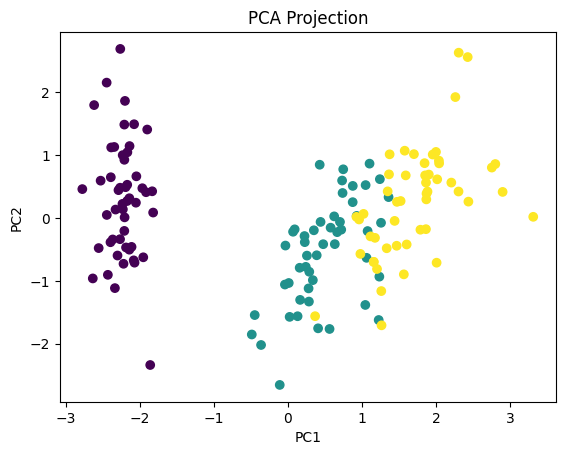

In [11]:


## Step 1: Import Libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

##Step 2: Load Data
data = load_iris()
X = data.data
y = data.target

##Step 3: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##Step 4: Apply PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## Step 5: Check Variance Retained
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

##Step 6: Visualize
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

What We Achieved We reduced: From 4 dimensions → 2 dimensions. While still preserving most of the structure. This is why PCA is so powerful.